# 03 - Model Selection and Training

## ES | Objetivo

Este notebook está diseñado para entrenar, evaluar y comparar diversos modelos de Machine Learning con el fin de predecir el nivel de riesgo de burnout (`burnout_risk`: `Low`, `Medium`, `High`) según las variables del entorno laboral.

Las etapas principales de este proceso incluyen:

* **Carga de datos:** Importar el conjunto de datos preprocesados.
* **Modelado:** Configuración y ajuste de los hiperparámetros de los modelos.
* **Entrenamiento y Validación:** Implementar una estrategia de validación cruzada durante el entrenamiento del modelo para garantizar la estabilidad y robustez de las métricas de evaluación.
* **Selección:** Determinar el modelo óptimo ajustando la estrategia para mitigar el desbalanceo de clases observado en el EDA.
* **Exportación:** Guardar el modelo con mejores prestaciones en formato `.joblib`.

---

## EN | Objective

This notebook is designed to train, evaluate, and compare various Machine Learning models to predict the burnout risk level (`burnout_risk`: `Low`, `Medium`, `High`) based on workplace environment variables.

The main stages of this process include:

* **Data Loading:** Importing the preprocessed dataset.
* **Modeling:** Setting up and tuning the models' hyperparameters.
* **Training and Validation:** Implementing a cross-validation strategy during model training to ensure the stability and robustness of the evaluation metrics.
* **Selection:** Determining the optimal model by adjusting the strategy to mitigate the class imbalance observed in EDA.
* **Exporting:** Saving the best-performing model in `.joblib` format.

## 3.0. Environment Setup and Imports

## ES
Carga de todas las librerías y módulos necesarios para esta fase del proyecto. Incluye herramientas para la manipulación de datos (`pandas`, `numpy`), la serialización del modelo (`joblib`), la división y validación de los datos (`scikit-learn`), así como los diferentes algoritmos de Machine Learning (Softmax Regression, Random Forest, XGBoost y SVM) que se entrenarán y compararán. También define una semilla de aleatoriedad (`RANDOM_STATE`) para garantizar que los resultados sean reproducibles.

---

## EN

Loading of all the libraries and modules required for this phase of the project. It includes tools for data manipulation (`pandas`, `numpy`), model serialization (`joblib`), data splitting and validation (`scikit-learn`), as well as the different Machine Learning algorithms (Softmax Regression, Random Forest, XGBoost, and SVM) that will be trained and compared. It also defines a random seed (`RANDOM_STATE`) to ensure the results are reproducible.


In [43]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score

RANDOM_STATE = 42

## 3.1. Data Loading

### ES

Preparación de los conjuntos de datos finales para la fase de modelado mediante dos acciones clave:

* **Carga de matrices empaquetadas:** Se importan los conjuntos de entrenamiento (`X_train`, `y_train`) y prueba (`X_test`, `y_test`) desde un archivo comprimido de NumPy (`.npz`). Este formato optimiza el almacenamiento y garantiza que los datos preprocesados conserven su estructura original.
* **Codificación ordinal jerárquica:** Dado que la variable objetivo (`burnout_risk`) tiene una naturaleza categórica con un orden lógico intrínseco, se utiliza `OrdinalEncoder` de scikit-learn. Se define explícitamente la jerarquía (`Low` $\rightarrow$ 0, `Medium` $\rightarrow$ 1, `High` $\rightarrow$ 2) para asegurar que el modelo interprete correctamente la progresión del riesgo de burnout, transformando las etiquetas de texto en valores numéricos enteros.

---

### EN

Preparation of the final datasets for the modeling phase through two key operations:

* **Loading Compressed Matrices:** The training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets are imported from a compressed NumPy archive (`.npz`). This format optimizes storage and ensures that the preprocessed data retains its original structure.
* **Hierarchical Ordinal Encoding:** Since the target variable (`burnout_risk`) is categorical with an intrinsic logical order, scikit-learn's `OrdinalEncoder` is used. The hierarchy is explicitly enforced (`Low` $\rightarrow$ 0, `Medium` $\rightarrow$ 1, `High` $\rightarrow$ 2) to ensure the models correctly interpret the progression of burnout risk, transforming text labels into integer values.

In [44]:
data_path = './data/processed/burnout_processed.npz'
print(f"Loading datasets from compressed archive: {data_path}  ...")

# Load the compressed .npz archive
with np.load(data_path, allow_pickle=True) as data:
    # Extract arrays using their internal file keys
    X_train = data['X_train.npy']
    X_test = data['X_test.npy']
    y_train = data['y_train.npy']
    y_test = data['y_test.npy']

# Define the exact hierarchy of burnout categories
# Enforce: low -> 0, Medium -> 1, High -> 2
custom_order = ['Low', 'Medium', 'High']

# Initialize OrdinalEncoder with the explicit custom order list
ordinal_encoder = OrdinalEncoder(categories=[custom_order])

# Reshape targets to 2D (-1, 1): mandatory for scikit-learn encoders
y_train_encoded = ordinal_encoder.fit_transform(y_train.reshape(-1, 1)).ravel().astype(int)
y_test_encoded = ordinal_encoder.transform(y_test.reshape(-1, 1)).ravel().astype(int)

print("\n--- Datasets Successfully Loaded ---")
print(f"X_train shape: {X_train.shape} | Target variables (y_train): {y_train_encoded.shape}")
print(f"X_test shape:  {X_test.shape}  | Target variables (y_test):  {y_test_encoded.shape}")
print(f"\nOrdinal categories mapped: {ordinal_encoder.categories_[0].tolist()}")

Loading datasets from compressed archive: ./data/processed/burnout_processed.npz  ...

--- Datasets Successfully Loaded ---
X_train shape: (1600, 11) | Target variables (y_train): (1600,)
X_test shape:  (400, 11)  | Target variables (y_test):  (400,)

Ordinal categories mapped: ['Low', 'Medium', 'High']


## 3.2. Model Configuration and Hyperparameter Spaces

### ES

Definición de un diccionario de configuración (`models_config`) para automatizar el entrenamiento. Para cada algoritmo (Regresión Softmax, Random Forest, XGBoost y SVM), se inicializa el modelo base con parámetros fijos (como la semilla de aleatoriedad) y se define su respectivo espacio de búsqueda de hiperparámetros (`params`). Esta estructura permitirá iterar de forma eficiente utilizando `RandomizedSearchCV`.

---

### EN

Definition of a configuration dictionary (`models_config`) to automate the training pipeline. For each algorithm (Softmax Regression, Random Forest, XGBoost, and SVM), the base model is initialized with fixed parameters (such as the random seed), and its respective hyperparameter search space (`params`) is specified. This structure enables efficient iteration using `RandomizedSearchCV`.

In [45]:
# Defining search spaces for RandomizedSearchCV
models_config = {
    'Softmax Regression': {
        'model': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE),
        'params': {'C': [0.01, 0.1, 1, 10]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
    },
    'SVM': {
        'model': SVC(probability=True, random_state=RANDOM_STATE),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
    }
}

## 3.3. Model Training and Hyperparameter Tuning with Cross-Validation

### ES

Ejecución el ciclo principal de entrenamiento, optimización y evaluación de los modelos definidos previamente. Los pasos clave que se realizan son:

* **Validación Cruzada Estratificada:** Configura un esquema de `StratifiedKFold` con 5 particiones (*splits*). Esto garantiza que la proporción original de las clases se mantenga constante en cada subconjunto de entrenamiento y validación, mitigando el impacto del desbalanceo de datos.
* **Búsqueda de Hiperparámetros:** Utiliza `RandomizedSearchCV` para evaluar de forma eficiente hasta 10 combinaciones aleatorias de parámetros para cada algoritmo, optimizando directamente la métrica `f1_macro` debido a la naturaleza desbalanceada del objetivo.
* **Diagnóstico de Sobreajuste (Overfitting):** Extrae y calcula el rendimiento promedio tanto en el set de entrenamiento como en el de validación cruzada (`Overfitting Gap`). Esto permite identificar si algún modelo ha memorizado los datos en lugar de generalizar correctamente.
* **Evaluación Final y Consolidación:** Evalúa los mejores estimadores encontrados utilizando el conjunto de prueba independiente (`X_test`), calculando su precisión (*Accuracy*) y puntaje F1. Finalmente, consolida todas las métricas en un DataFrame de `pandas` ordenado de mayor a menor rendimiento para facilitar la toma de decisiones.

---

### EN

Execution of the main training, optimization, and evaluation pipeline for the previously defined models. The key steps include:

* **Stratified Cross-Validation:** Sets up a 5-fold `StratifiedKFold` strategy. This ensures that the original class proportions are preserved across all validation splits, mitigating the impact of class imbalance.
* **Hyperparameter Tuning:** It utilizes `RandomizedSearchCV` to efficiently explore up to 10 random parameter combinations for each algorithm, optimizing for the `f1_macro` metric to account for class imbalance.
* **Overfitting Diagnostics:** It extracts and compares the average performance on both the training and cross-validation sets (`Overfitting Gap`), allowing for an immediate assessment of how well each model generalizes.
* **Final Evaluation and Summary:** The best-performing estimator for each algorithm is evaluated on the unseen test set (`X_test`) using Accuracy and F1-Score. All metrics are then consolidated into a structured `pandas` DataFrame, sorted by test performance for easy analysis.

In [46]:
best_models = {}
results_summary = []

# Define a stratified K-Fold cross-validator
# This ensures class proportions are preserved across all 5 validation splits
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("\n--- Starting Randomized Search with 5-Fold Stratified CV ---")

for model_name, config in models_config.items():
    print(f"Training {model_name}...")

    # Calculate the total grid size: Multiply the lengths of all list parameters together
    grid_size = np.prod([len(v) for v in config['params'].values()])

    # Dynamically adjust n_iter so it never exceeds the total parameter space
    adjusted_n_iter = min(10, grid_size)

    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=adjusted_n_iter,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        return_train_score=True
    )

    search.fit(X_train, y_train_encoded)
    best_models[model_name] = search.best_estimator_

    # Extract cross-validation metrics to analyze overfitting
    best_index = search.best_index_
    cv_train_score = search.cv_results_['mean_train_score'][best_index]
    cv_val_score = search.cv_results_['mean_test_score'][best_index]

    # Evaluate on the test set
    y_pred_test = search.predict(X_test)
    test_f1 = f1_score(y_test_encoded, y_pred_test, average='macro')
    test_acc = accuracy_score(y_test_encoded, y_pred_test)

    # Overfitting gap
    overfitting_gap = cv_train_score - cv_val_score

    results_summary.append({
        'Model': model_name,
        'Best Params': search.best_params_,
        'CV Train F1 (Macro)': round(cv_train_score, 4),
        'CV Val F1 (Macro)': round(cv_val_score, 4),
        'Test F1 (Macro)': round(test_f1, 4),
        'Test Accuracy': round(test_acc, 4),
        'Overfitting Gap': round(overfitting_gap, 4)
    })

# Convert results to a pandas DataFrame for structured analysis
df_results = pd.DataFrame(results_summary)
print("\n--- Model Performance Summary ---")
print(df_results.sort_values(by='Test F1 (Macro)', ascending=False).to_string())


--- Starting Randomized Search with 5-Fold Stratified CV ---
Training Softmax Regression...
Training Random Forest...
Training XGBoost...
Training SVM...

--- Model Performance Summary ---
                Model                                                     Best Params  CV Train F1 (Macro)  CV Val F1 (Macro)  Test F1 (Macro)  Test Accuracy  Overfitting Gap
2             XGBoost     {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2}               1.0000             0.9377           0.9857         0.9875           0.0623
3                 SVM                                   {'kernel': 'linear', 'C': 10}               0.9822             0.9683           0.9837         0.9850           0.0140
0  Softmax Regression                                                       {'C': 10}               0.9813             0.9652           0.9819         0.9825           0.0161
1       Random Forest  {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}               1.0000    

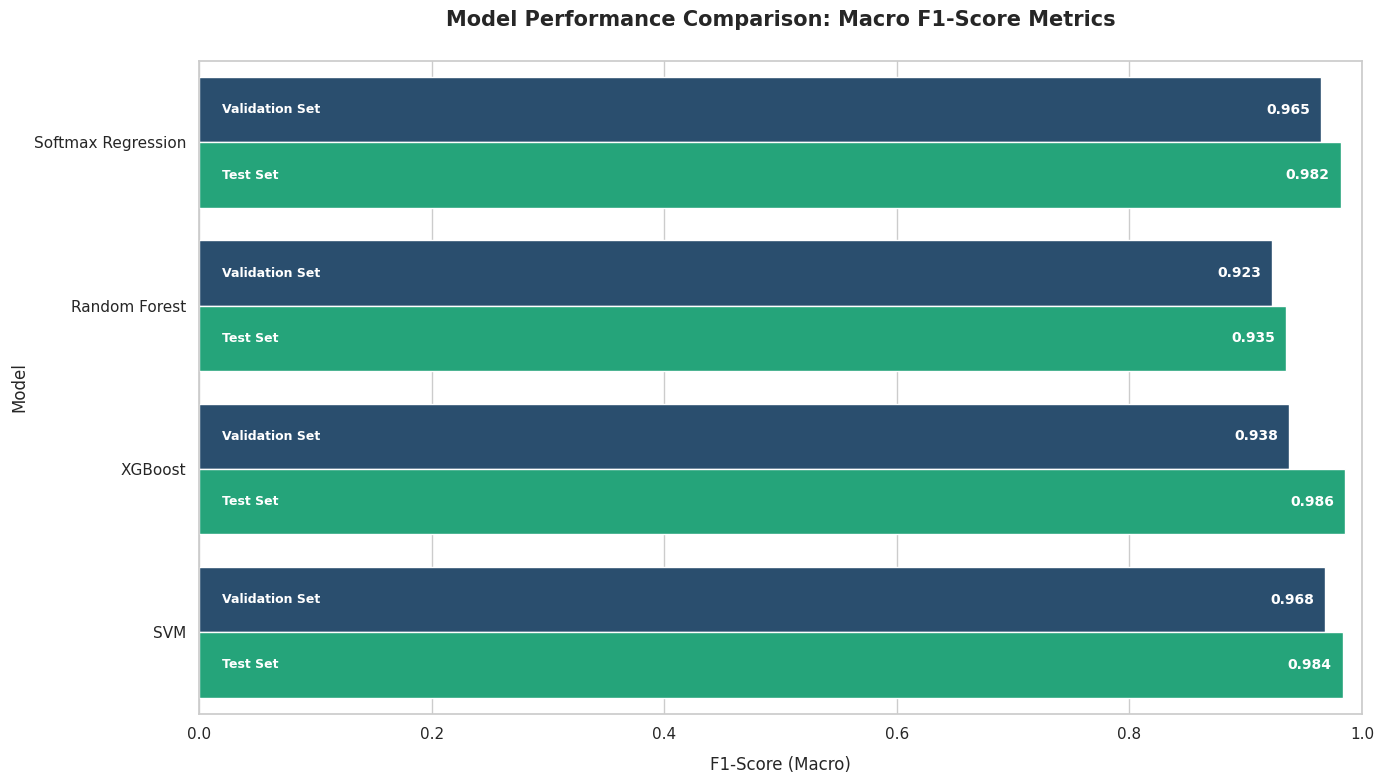

In [57]:
# Visual performance comparison

# Set plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Copy the dataframe to avoid altering the original results table
df_results_clean = df_results.copy()

# Melt the cleaned dataframe to reshape it for seaborn grouped barplot format
df_plot = df_results_clean.melt(
    id_vars=['Model'],
    value_vars=['CV Val F1 (Macro)', 'Test F1 (Macro)'],
    var_name='Evaluation Phase',
    value_name='F1-Score'
)

# Clean up label strings directly for the bar mapping
df_plot['Evaluation Phase'] = df_plot['Evaluation Phase'].replace({
    'CV Val F1 (Macro)': 'Cross-Validation',
    'Test F1 (Macro)': 'Test Set'
})

# Define a custom corporate blue palette
corporate_blues = {
    'Cross-Validation': '#1f4e79',
    'Test Set': '#10B981'
}

# Create the horizontal grouped bar plot
ax = sns.barplot(
    data=df_plot,
    x='F1-Score',
    y='Model',
    hue='Evaluation Phase',
    palette=corporate_blues,
    orient='h',
    legend=False
)

# Number of models trained
num_models = len(df_results_clean['Model'].unique())

# Add descriptive labels
for idx, p in enumerate(ax.patches):
    if p.get_width() > 0:
        # Calculate coordinates
        bar_y = p.get_y() + p.get_height() / 2.
        bar_width = p.get_width()

        # If the index is less than the number of models, it belongs to the group Cross-Validation
        if idx < num_models:
            phase_text = "Validation Set"
            text_color = '#FFFFFF'
        else:
            phase_text = "Test Set"
            text_color = '#FFFFFF'

        # Place the phase name near the start of the bar
        ax.annotate(
            phase_text,
            (0.02, bar_y),
            ha='left',
            va='center',
            fontsize=9,
            fontweight='bold',
            color=text_color
        )

        # Place the numeric score just before the bar tip
        number_text = f"{bar_width:.3f}"
        ax.annotate(
            number_text,
            (bar_width, bar_y),
            ha='right',
            va='center',
            xytext=(-8, 0),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold',
            color=text_color
        )

# Title and axes styling
plt.title('Model Performance Comparison: Macro F1-Score Metrics', fontsize=15, fontweight='bold', pad=25)
plt.xlabel('F1-Score (Macro)', fontsize=12, labelpad=10)

# Set the maximum limit of the X axis strictly to 1.0
plt.xlim(0, 1.0)

plt.tight_layout()
plt.show()

### ES | Resumen y Conclusiones

La tabla resume la evaluación de cuatro arquitecturas de Machine Learning optimizadas.

* **XGBoost (Líder en Rendimiento):** Alcanza la métrica más alta en el conjunto de prueba con un **Test F1 de 0.9857** y una precisión global (**Accuracy**) del **98.75%**. Aunque memoriza el conjunto de entrenamiento por completo ($\text{CV Train F1} = 1.0$), su capacidad para generalizar con datos nuevos es sobresaliente.
* **SVM (El más Estable):** Presenta, también, un rendimiento sobresaliente con un **Test F1 de 0.9837**. Lo más destacable de este modelo es su consistencia: tiene el **Overfitting Gap más bajo (0.0140)**, lo que significa que el comportamiento observado en la validación simula con extrema precisión el entorno de producción real.
* **Softmax Regression:** Registra métricas muy buenas (**Test F1 de 0.9819** y **Accuracy de 98.25%**). Su bajo margen de sobreajuste (0.0161) muestra que las relaciones entre las variables de burnout y el objetivo se pueden resolver de forma eficiente mediante fronteras de decisión lineales.
* **Random Forest (Menos Competitivo):** Cierra la lista con un **Test F1 de 0.9350**. Al igual que XGBoost, alcanza un aprendizaje perfecto en entrenamiento (1.0), pero sufre la mayor degradación en datos nuevos con un **Overfitting Gap de 0.0770**, lo que indica una ligera tendencia a sobreajustar los patrones de la muestra inicial.

Basándonos en un equilibrio entre **rendimiento puro**, **generalización** y **estabilidad**, extraemos las siguientes conclusiones para el proyecto:

#### 1. Selección del mejor Modelo: **XGBoost**

Se propone **XGBoost** como el modelo elegido para el despliegue. No solo ofrece la mejor tasa de acierto macro (minimizando los falsos negativos en casos críticos de burnout), sino que su alta puntuación en el conjunto de Test se contrapone a la idea de que el valor de $1.0$ en Train fuera un sobreajuste destructivo; el modelo realmente capturó patrones de comportamiento altamente transferibles.

#### 2. Alternativa por Eficiencia y Despliegue: **SVM / Softmax**

Si el entorno de producción final de la empresa exige un consumo mínimo de recursos computacionales o requiere una explicación directa de coeficientes (interpretabilidad matemática inmediata ante comités de Recursos Humanos), **SVM con kernel lineal** o **Softmax Regression** son buenas alternativas. Su pérdida de rendimiento respecto a XGBoost es marginal ($< 0.4\%$), pero su ligereza arquitectónica y estabilidad los convierten en alternativas viables para entornos de producción.

#### 3. Diagnóstico del Overfitting

Los resultados muestra que los algoritmos basados en ensambles de árboles (XGBoost y Random Forest) tienden a memorizar con facilidad las muestras de entrenamiento. Sin embargo, gracias a las restricciones de hiperparámetros aplicadas (`max_depth: 3` en XGBoost), se logró contener el riesgo, transformando esa capacidad de memorización en precisión.

---

### EN | Summary and Conclusions

The table summarizes the evaluation of four optimized Machine Learning architectures.

* **XGBoost (Performance Leader):** Achieves the highest metric on the test set with a **Test F1 of 0.9857** and an overall accuracy (**Accuracy**) of **98.75%**. Although it completely memorizes the training set ($\text{CV Train F1} = 1.0$), its ability to generalize to new data is outstanding.
* **SVM (Most Stable):** Also delivers outstanding performance with a **Test F1 of 0.9837**. The most remarkable aspect of this model is its consistency: it has the **lowest Overfitting Gap (0.0140)**, meaning that the behavior observed during validation accurately simulates the real production environment.
* **Softmax Regression:** Records very strong metrics (**Test F1 of 0.9819** and **Accuracy of 98.25%**). Its low overfitting margin (0.0161) shows that the relationships between burnout variables and the target can be efficiently resolved using linear decision boundaries.
* **Random Forest (Least Competitive):** Closes the list with a **Test F1 of 0.9350**. Like XGBoost, it achieves perfect learning during training (1.0), but suffers the highest degradation on new data with an **Overfitting Gap of 0.0770**, indicating a slight tendency to overfit the patterns of the initial sample.

Based on a balance between **pure performance**, **generalization**, and **stability**, we draw the following conclusions for the project:

#### 1. Best Model Selection: **XGBoost**

**XGBoost** is proposed as the selected model for deployment. Not only does it offer the highest macro success rate (minimizing false negatives in critical burnout cases), but its high score on the test set counters the idea that the $1.0$ value in Train was a destructive overfit; the model truly captured highly transferable behavioral patterns.

#### 2. Efficiency and Deployment Alternative: **SVM / Softmax**

If the company's final production environment demands minimal computational resource consumption or requires a direct explanation of coefficients (immediate mathematical interpretability for HR committees), **SVM with a linear kernel** or **Softmax Regression** are good alternatives. Their performance loss compared to XGBoost is marginal ($< 0.4\%$), but their architectural lightness and stability make them highly viable alternatives for production environments.

#### 3. Overfitting Diagnosis

The results show that algorithms based on tree ensembles (XGBoost and Random Forest) tend to easily memorize the training samples. However, thanks to the hyperparameter constraints applied (`max_depth: 3` in XGBoost), this risk was successfully contained, turning that memorization capacity into high precision.

## 3.4. Model Serialisation and Export

### ES

Este apartado final se encarga de persistir el mejor modelo entrenado en el almacenamiento local utilizando la librería `joblib`.

La **serialización** es el proceso mediante el cual se congela el estado del modelo (incluyendo su arquitectura, pesos y los hiperparámetros optimizados) y se convierte en un archivo binario. Esto evita la necesidad de volver a ejecutar el pipeline de entrenamiento en el futuro, garantizando la portabilidad del modelo para su posterior integración y despliegue en un entorno de producción o módulos de inferencia.

---

### EN

This final section handles the persistence of the best-performing trained model into local storage using the `joblib` library.

**Serialization** is the process of freezing the model's current state (including its architecture, weights, and optimized hyperparameters) and converting it into a binary file. This eliminates the need to re-run the entire training pipeline in the future, ensuring the model's portability for seamless integration and deployment into a production environment or inference modules.

In [60]:
# Pick the best performing model based on Test F1-Score
best_model_name = df_results.sort_values(by='Test F1 (Macro)', ascending=False).iloc[0]['Model']
best_model = best_models[best_model_name]

print(f"\nChosen model for production: {best_model_name}")

# If the winning model is XGBoost, inject metadata into its Booster
if best_model_name == 'XGBoost':
    # Convert list to a comma-separated string since Booster attributes must be strings
    best_model.get_booster().set_attr(target_classes="Low,Medium,High")

# Create target directory if it does not exist
os.makedirs('./models', exist_ok=True)
model_output_path = './models/best_burnout_model.joblib'

# Serialise model to disk
joblib.dump(best_model, model_output_path)
print(f"Model saved to {model_output_path}")


Chosen model for production: XGBoost
Model saved to ./models/best_burnout_model.joblib
